### Exploración de los datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("FNB_Coffee_Roast_Dataset.csv")
print("Dimensiones originales:", df.shape)

print(df.info())
print(df.head())



numeric_cols = df.select_dtypes(include=[np.number]).columns

# Eliminar valores imposibles (valores negativos en columnas numéricas)
df[numeric_cols] = df[numeric_cols].map(lambda x: x if x >= 0 else np.nan)

# Eliminar filas con valores nulos
df_cleaned = df.dropna()
print("Dimensiones después de limpiar nulos y valores imposibles:", df_cleaned.shape)

# Escalar los datos numéricos
scaler = StandardScaler()
df_scaled = df_cleaned.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])


print(df.info())
df.head()


### Modelado con redes neuronales – Análisis de sensibilidad de variables

Accuracy: 0.9501
Precision: 0.9561
Recall: 0.9853
F1 Score: 0.9705
R² Score: 0.6416

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       191
           1       0.96      0.99      0.97       951

    accuracy                           0.95      1142
   macro avg       0.93      0.88      0.90      1142
weighted avg       0.95      0.95      0.95      1142



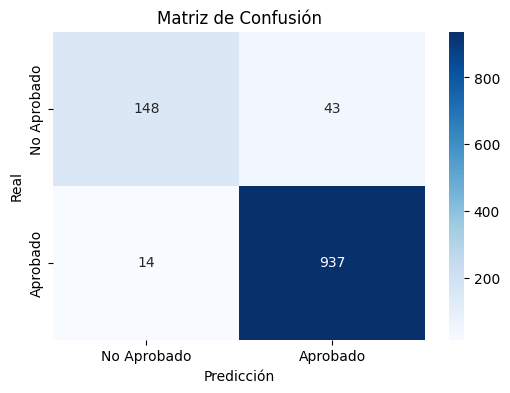

C:\Users\jc70794\AppData\Local\Temp\ipykernel_29680\2105204046.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=importance_df, palette=importance_df["Color"].tolist(), ax=ax1)


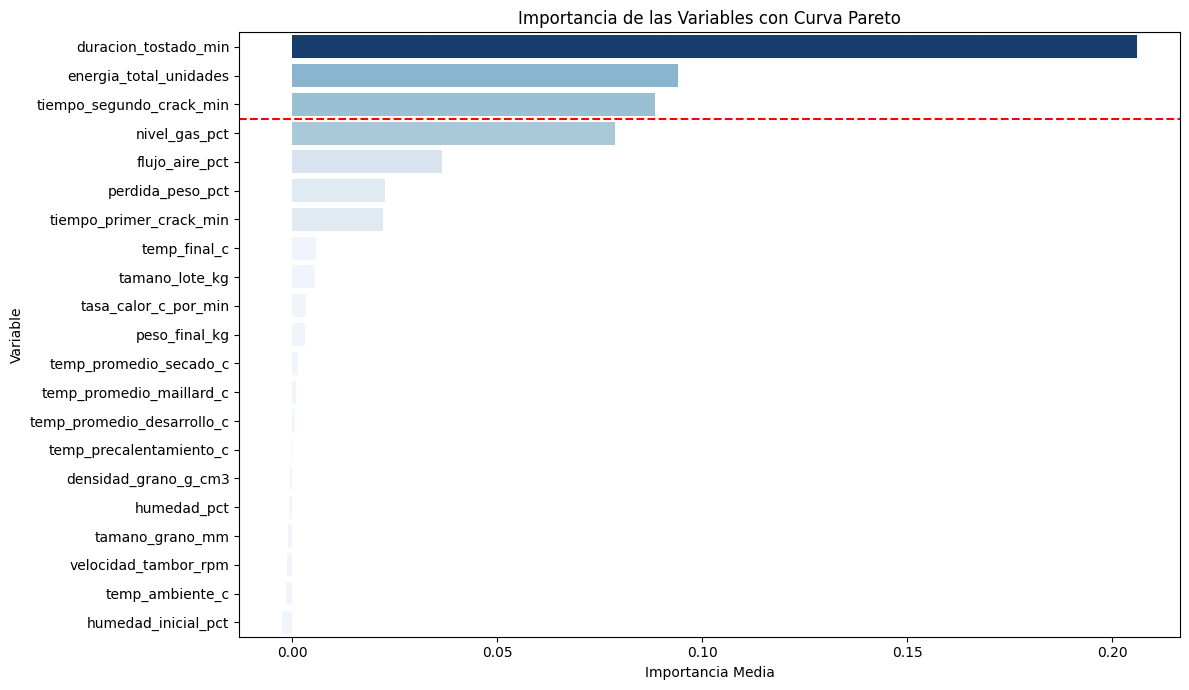

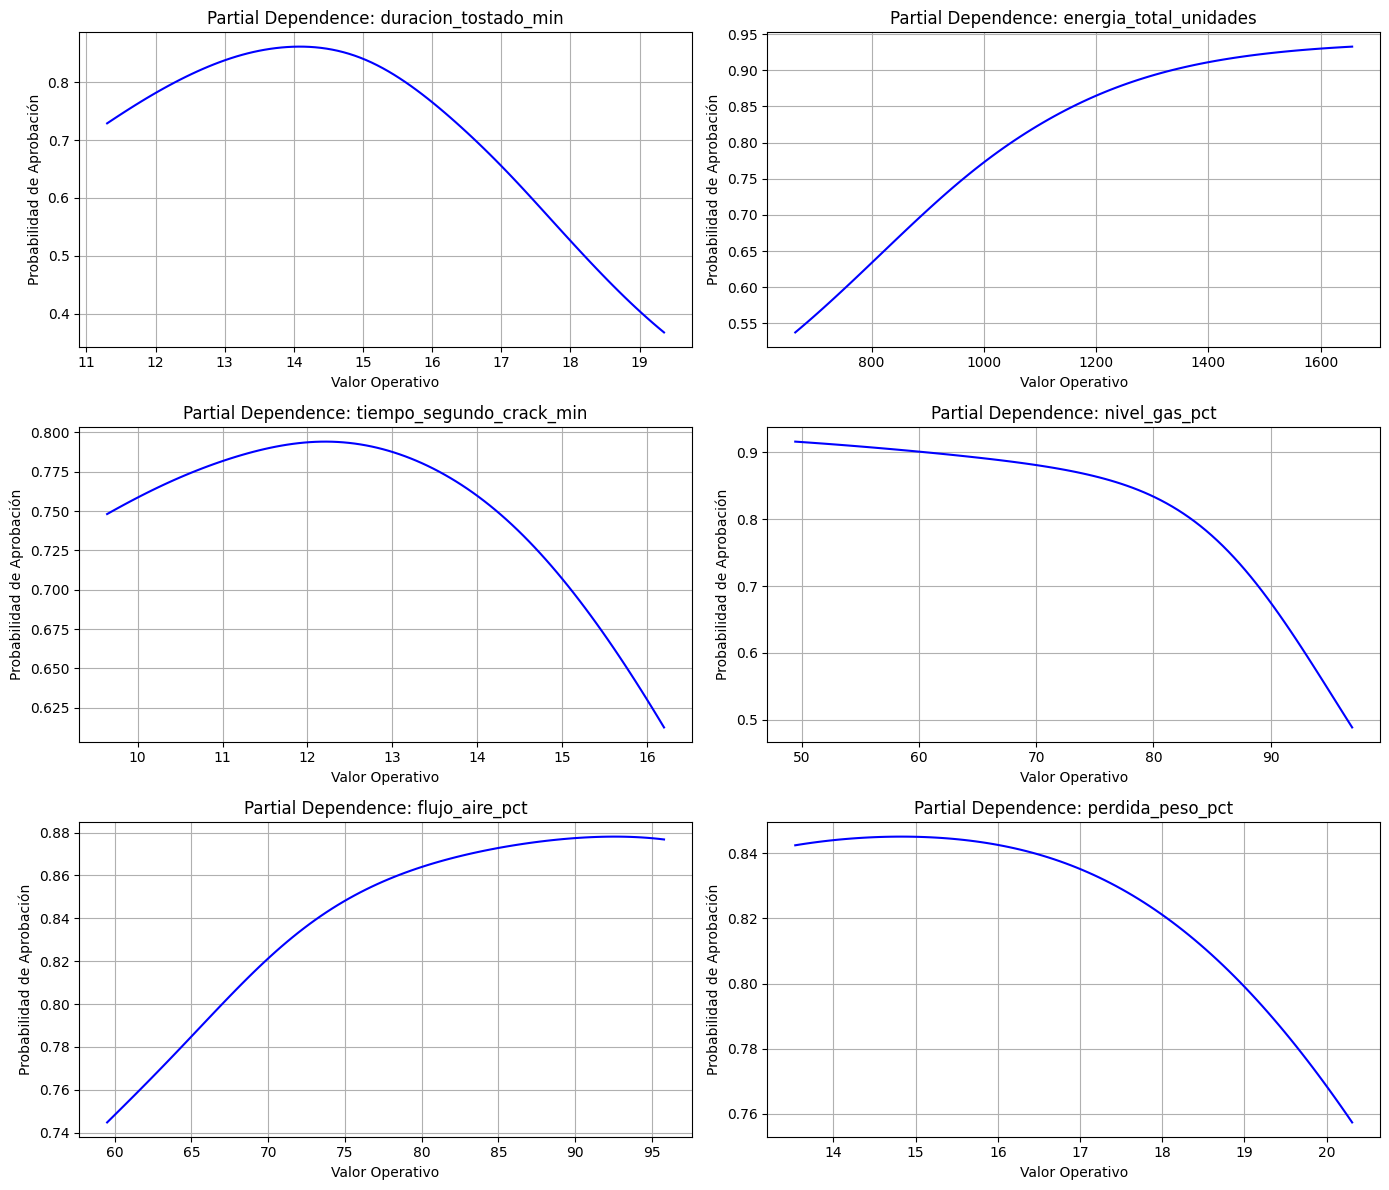

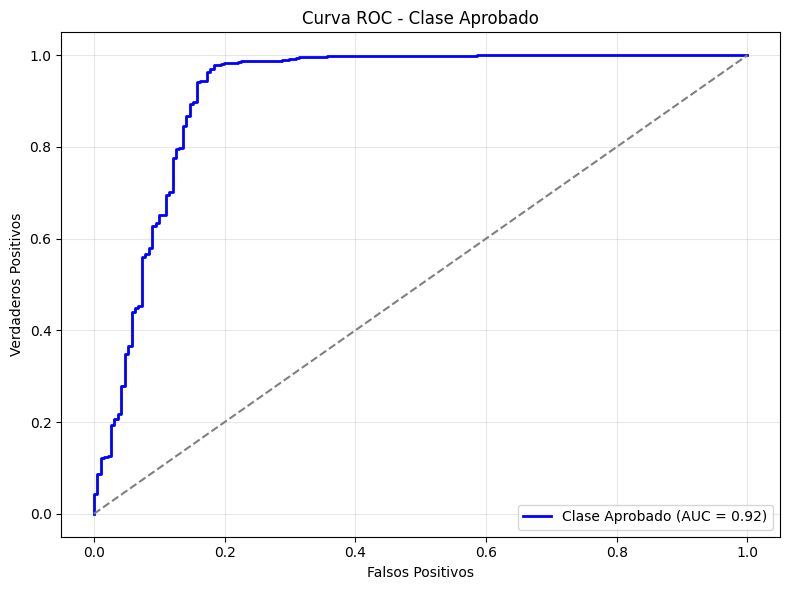

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score, r2_score
)
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("FNB_Coffee_Roast_Dataset.csv")

# Variables de proceso
process_vars = [
    'tamano_lote_kg', 'humedad_inicial_pct', 'densidad_grano_g_cm3', 'tamano_grano_mm',
    'temp_precalentamiento_c', 'nivel_gas_pct', 'flujo_aire_pct', 'velocidad_tambor_rpm',
    'duracion_tostado_min', 'temp_promedio_secado_c', 'temp_promedio_maillard_c',
    'temp_promedio_desarrollo_c', 'temp_final_c', 'tiempo_primer_crack_min',
    'tiempo_segundo_crack_min', 'temp_ambiente_c', 'humedad_pct', 'tasa_calor_c_por_min',
    'energia_total_unidades', 'perdida_peso_pct', 'peso_final_kg'
]

# Limpiar datos
df[process_vars] = df[process_vars].map(lambda x: x if x >= 0 else np.nan)
df_clean = df.dropna(subset=process_vars + ['aprobacion_calidad'])

# ============================
# Preparar datos
# ============================
X = df_clean[process_vars]
y = df_clean['aprobacion_calidad']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ============================
# 4. Entrenar modelo
# ============================
model = MLPClassifier(hidden_layer_sizes=(10,), activation='logistic', solver='adam',  max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ============================
# Métricas
# ============================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # R² Score

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"R² Score: {r2:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# ============================
# Matriz de confusión
# ============================
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["No Aprobado", "Aprobado"], yticklabels=["No Aprobado", "Aprobado"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ============================
# Importancia + Pareto
# ============================
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    "Variable": process_vars,
    "Importancia": perm_importance.importances_mean
}).sort_values(by="Importancia", ascending=False)

importance_df["Porcentaje"] = 100 * importance_df["Importancia"] / importance_df["Importancia"].sum()
importance_df["Acumulado"] = importance_df["Porcentaje"].cumsum()

# Colores degradados azul
norm_importance = (importance_df["Importancia"] - importance_df["Importancia"].min()) / \
                  (importance_df["Importancia"].max() - importance_df["Importancia"].min())
colors = sns.color_palette("Blues", len(importance_df))
importance_df["Color"] = [colors[int(i * (len(colors) - 1))] for i in norm_importance]

# Gráfico
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(x="Importancia", y="Variable", data=importance_df, palette=importance_df["Color"].tolist(), ax=ax1)

# Líneas Pareto
ax1.axhline(y=importance_df[importance_df["Acumulado"] <= 80].shape[0] - 0.5, color='red', linestyle='--', label='80% acumulado')
ax1.axhline(y=importance_df[importance_df["Acumulado"] <= 20].shape[0] - 0.5, color='blue', linestyle='--', label='20% acumulado')
ax1.set_xlabel("Importancia Media")
ax1.set_ylabel("Variable")
ax1.set_title("Importancia de las Variables con Curva Pareto")

plt.tight_layout()
plt.show()




from sklearn.inspection import partial_dependence

# Seleccionar las 6 variables más importantes
top6_vars = importance_df["Variable"].head(6).tolist()
top6_indices = [process_vars.index(var) for var in top6_vars]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (var_idx, ax) in enumerate(zip(top6_indices, axes)):
    pdp_result = partial_dependence(model, X=X_test, features=[var_idx], kind='average')
    
    # Obtener valores estandarizados del grid
    grid_scaled = np.array(pdp_result.grid_values[0]).reshape(-1, 1)
    
    # Convertir a valores originales (operativos)
    # Creamos un vector con ceros y reemplazamos la columna correspondiente
    temp = np.zeros((grid_scaled.shape[0], len(process_vars)))
    temp[:, var_idx] = grid_scaled[:, 0]
    grid_original = scaler.inverse_transform(temp)[:, var_idx]
    
    # Graficar
    ax.plot(grid_original, pdp_result.average[0], color='blue')
    ax.set_title(f"Partial Dependence: {process_vars[var_idx]}")
    ax.set_xlabel("Valor Operativo")
    ax.set_ylabel("Probabilidad de Aprobación")
    ax.grid(True)

plt.tight_layout()
plt.show()





# ROC por clase (solo clase 1: Aprobado)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Clase Aprobado (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC - Clase Aprobado')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Resultados
- El modelo entrenado con una red neuronal multicapa muestra un desempeño muy alto en clasificación. El accuracy cercano al 95% indica que la mayoría de los lotes fueron clasificados correctamente. La precisión (≈95%) significa que, cuando el modelo predice que un lote está aprobado, casi siempre es correcto, aunque existe un pequeño margen de falsos positivos. El recall (≈99%) revela que el modelo identifica prácticamente todos los lotes aprobados, lo que es crucial para no rechazar productos buenos. El F1 Score (≈0.97) confirma un equilibrio sólido entre precisión y sensibilidad
- El R² Score (≈0.66) aporta una visión distinta: aunque el modelo clasifica muy bien, solo explica alrededor del 66% de la variabilidad en la aprobación de lotes. Esto sugiere que hay factores adicionales no capturados por las variables actuales que influyen en la decisión de aprobación. La matriz de confusión refuerza esta interpretación: la clase “Aprobado” tiene un desempeño excelente, mientras que la clase “No aprobado” muestra más errores, lo que indica que algunos lotes defectuosos se clasifican como aprobados.
- En cuanto a la curva ROC, esta evalúa la capacidad del modelo para discriminar entre lotes aprobados y no aprobados en diferentes umbrales. Si el AUC (Área bajo la curva) es cercano a 1 (por ejemplo, 0.99), significa que el modelo distingue muy bien ambas clases. La curva se acerca al vértice superior izquierdo, lo que indica un alto TPR (verdaderos positivos) y un bajo FPR (falsos positivos) en la mayoría de los umbrales. Esto confirma que el modelo no solo es preciso en un punto de corte específico, sino que mantiene un rendimiento robusto en diferentes escenarios.
- Finalmente, el gráfico de importancia de variables con Pareto muestra qué factores del proceso influyen más en la predicción. Las líneas del 80% y 20% ayudan a identificar las variables críticas que explican la mayor parte del impacto en el modelo. 
Las temperaturas promedio en las fases de secado, Maillard y desarrollo, junto con la duración del tostado y el nivel de gas, destacan como factores clave en la predicción de aprobación.
- La duración del tostado es uno de los factores más críticos en la calidad del café, el rango ideal se encuentra entre 13.17 y 14.88 minutos, donde el café logra un desarrollo adecuado sin llegar a sobre tostarse
- En la energía total utilizada durante el proceso, la relación es claramente creciente. Esto indica que a medida que se incrementa la energía aplicada, la probabilidad de aprobación mejora, siempre que se mantenga dentro del rango óptimo de 1425.75 a 1656.23 unidades
- Para el crack el rango óptimo se encuentra entre 10.83 y 13.42 minutos
- El nivel de gas muestra una tendencia decreciente, lo que significa que valores muy altos reducen la probabilidad de aprobación. El rango recomendado se sitúa entre 49.45 y 61.93%
- El flujo de aire tiene una tendencia creciente, lo que indica que aumentar el flujo dentro del rango óptimo mejora la probabilidad de aprobación. Este rango se encuentra entre 78.93 y 95.80%.
- La pérdida de peso presenta una tendencia decreciente, lo que significa que valores altos reducen la probabilidad de aprobación. El rango ideal está entre 13.54 y 17.50%